In [ ]:
import math
import sys
import mpire
import os

os.environ["OMP_NUM_THREADS"] = "1"
import time
import multiprocessing
from mpire import WorkerPool
from pprint import pprint
import itertools
num_cores =max(multiprocessing.cpu_count()//2,1)
import shutil
import random
from multiprocessing import Manager
from pprint import pprint

from ragatouille import RAGPretrainedModel


from sentence_transformers import SentenceTransformer
from voyager import Index, Space

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

from ragatouille.utils import get_wikipedia_page
from ragatouille.data import CorpusProcessor

class MyExistingRetrievalPipeline:
    index: Index
    embedder: SentenceTransformer

    def __init__(self, embedder_name: str = "BAAI/bge-small-en-v1.5"):
        self.embedder = SentenceTransformer(embedder_name)
        self.collection_map = {}
        self.index = Index(
            Space.Cosine,
            num_dimensions=self.embedder.get_sentence_embedding_dimension(),
        )

    def index_documents(self, documents: list[str]) -> None:
        # There's very few documents in our example, so we don't bother with batching
        for document in documents:
            self.collection_map[self.index.add_item(self.embedder.encode(document['content']))] = document['content']

    def query(self, query: str, k: int = 10) -> list[str]:
        query_embedding = self.embedder.encode(query)
        to_return = []
        for idx in self.index.query(query_embedding, k=k)[0]:
            to_return.append(self.collection_map[idx])
        return to_return





def parallel_process_recipe(get_wikipedia_pages):
    # print(f"get_wikipedia_pages: {get_wikipedia_pages}")
    recipe = get_wikipedia_page(get_wikipedia_pages)
    return {"individual_recipe":recipe}


def create_rasengan(recipe_items,rasengan_steps):
    top_n_recipes = 1
    RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
    existing_pipeline = MyExistingRetrievalPipeline()

    corpus_processor = CorpusProcessor()
    # actual_recipe = "Create a recipe like ratatouille from:-"
    recipe_list = set("Create a recipe like ratatouille from:-".split())

    for k,v in recipe_items.items():
      for sub_recipe in v:
        x = f"in {k}, add {sub_recipe}".lower().split()
        # actual_recipe+=f"In {k}, add {sub_recipe}.\n"
        recipe_list.update(x)

    results = [{"get_wikipedia_pages":recipe} for recipe in recipe_list]
    with WorkerPool(n_jobs=num_cores,daemon=False) as pool:
            results = pool.map(parallel_process_recipe, results, progress_bar=True)
    documents = [result["individual_recipe"] for result in results]
    documents = corpus_processor.process_corpus(documents, chunk_size=10000)

    existing_pipeline.index_documents(documents)

    actual_recipe = "Create rasengan by following this steps :- \n"
    for i in range(1,1+len(rasengan_steps)):
      actual_recipe+=f"Step {i}. {rasengan_steps[i-1]}\n"
    query = actual_recipe
    raw_results = existing_pipeline.query(query, k=top_n_recipes)

    # Replace the model version with your required version if needed
    pipeline = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    )

    pipeline = pipeline.to('cuda')

    ar = []
    for i in range(1,1+len(raw_results)):
      im = pipeline(prompt=f"{raw_results[i-1]}").images[0]
      ar.append(im)

    return [{f"Tasty Recipe {i}":raw_results[i-1],f"Actual Recipe {i}":ar[i-1]} for i in range(1,1+len(raw_results))]


recipe_items = {
    "necessary materials":[
        "1 ball of transparent acrylic",
        "1 pen",
        "1 little engine",
        "4 blue leds",
        "2 switch on, off",
        "4 coin batteries 3v",
        "1 9V battery",
        "1 9V battery socket"
    ]
}

rasengan_steps = [
    "drill a hole in the acrylic ball after docking the pen barrel",
    "connect two LEDs and paste into one part of the ball of acrylic",
    "in the acrylic ball que puts the pen barrel drill a hole and paste the switch on, off",
    "connect the other two LEDs is near Paste switch",
    "Do all the links of the LEDs of both sides of the ball, take the 3V batteries and turn on the LEDs,paste the batteries on the ball to not be swinging",
    "close the ball, make a play for the hand, you can use a piece of iron, cardboard, platico.paste the little engine on the part for the hand,",
    "call the little engine in the socket for battery,turn on the switch,Paste it on a piece of wood or cardboard,place the 9v battery to start the engine",
    "gift arm snap the ball on the motor shaft, (the barrel of the pen fits the little engine shaft) call leds call the little engine to start spinning ready finalized"
]
recipe_items["necessary materials"]+=rasengan_steps
final_recipe = create_rasengan(recipe_items,rasengan_steps)



/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1232/1235662152.py:40: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  num_dimensions=self.embedder.get_sentence_embedding_dimension(),
 28%|██▊       | 26/94 [00:04<00:09,  6.82it/s]

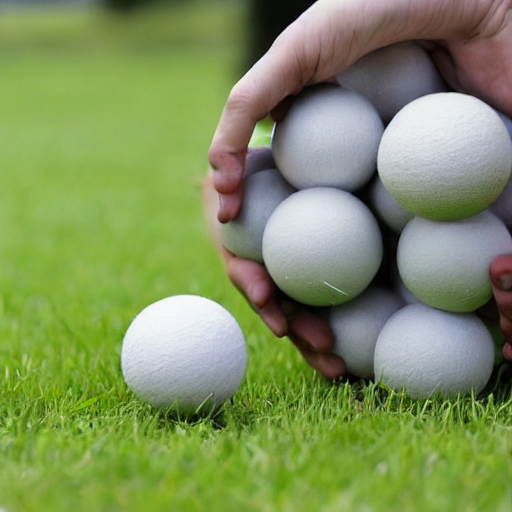

In [9]:
# final_recipe[0]['Tasty Recipe 1']
final_recipe[0]['Actual Recipe 1']

In [1]:
!pip install -r /content/requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirement